#Analyse und Prognose der Windgeschwindigkeit in Würzburg

##- Datenimport

In [1]:
import os
import pandas as pd

# ── Repo klonen (dev branch) ──────────────────────────────────
os.system("rm -rf Menden_S26_clean")
os.system("git clone https://github.com/cladensk334/Menden_S26_clean.git")
print("✅ Repo geklont (dev branch)")

# ── Daten laden ───────────────────────────────────────────────
wind_clean = pd.read_csv(
    "Menden_S26_clean/data/originals&cleaned/wind_bereinigt.csv",
    index_col="datum",
    parse_dates=True
)["windgeschwindigkeit_ms"]

#wind_clean = wind_clean[wind_clean.index >= "1966-01-01"]
#wind_clean = wind_clean[wind_clean.index <= "2026-01-11"]

print(f"✅ Wind Daten geladen")
print(f"   Zeitraum:      {wind_clean.index[0].date()} bis {wind_clean.index[-1].date()}")
print(f"   Beobachtungen: {len(wind_clean)}")
print(f"   Fehlende Werte: {wind_clean.isna().sum()}")

✅ Repo geklont (dev branch)
✅ Wind Daten geladen
   Zeitraum:      1966-01-01 bis 2026-01-11
   Beobachtungen: 21926
   Fehlende Werte: 0


## - Deskriptive Analyse  – Wind Geschwindigkeit (FM)

In [2]:
import pandas as pd
import numpy as np

# ── Grundlegende Statistiken ─────────────────────────────────
print("Deskriptive Statistiken\n")

stats = pd.DataFrame({
    "Kennzahl": [
        "Anzahl Beobachtungen",
        "Mittelwert (m/s)",
        "Median (m/s)",
        "Standardabweichung (m/s)",
        "Minimum (m/s)",
        "Maximum (m/s)",
        "25% Quantil (m/s)",
        "75% Quantil (m/s)",
        "Schiefe (Skewness)",
        "Wölbung (Kurtosis)"
    ],
    "Wert": [
        len(wind_clean),
        round(wind_clean.mean(), 4),
        round(wind_clean.median(), 4),
        round(wind_clean.std(), 4),
        round(wind_clean.min(), 4),
        round(wind_clean.max(), 4),
        round(wind_clean.quantile(0.25), 4),
        round(wind_clean.quantile(0.75), 4),
        round(wind_clean.skew(), 4),
        round(wind_clean.kurt(), 4)
    ]
})

print(stats.to_string(index=False))

# ── Analyse nach Jahrzehnt ───────────────────────────────────
print("\n Mittelwert pro Jahrzehnt \n")

wind_df = wind_clean.to_frame(name="FM")
wind_df["Jahrzehnt"] = (wind_df.index.year // 10) * 10
jahrzehnt = wind_df.groupby("Jahrzehnt")["FM"].agg(
    Mittelwert="mean",
    Std="std",
    Min="min",
    Max="max"
).round(3)

print(jahrzehnt.to_string())

# ── Analyse nach Monat ───────────────────────────────────────
print("\n Mittelwert pro Monat \n")

wind_df["Monat"] = wind_df.index.month
monate = {1:"Jan", 2:"Feb", 3:"Mär", 4:"Apr", 5:"Mai", 6:"Jun",
          7:"Jul", 8:"Aug", 9:"Sep", 10:"Okt", 11:"Nov", 12:"Dez"}

monat_stats = wind_df.groupby("Monat")["FM"].agg(
    Mittelwert="mean",
    Std="std",
    Min="min",
    Max="max"
).round(3)
monat_stats.index = monat_stats.index.map(monate)

print(monat_stats.to_string())

Deskriptive Statistiken

                Kennzahl       Wert
    Anzahl Beobachtungen 21926.0000
        Mittelwert (m/s)     3.0992
            Median (m/s)     2.7000
Standardabweichung (m/s)     1.7257
           Minimum (m/s)     0.0000
           Maximum (m/s)    14.9000
       25% Quantil (m/s)     1.9000
       75% Quantil (m/s)     3.9000
      Schiefe (Skewness)     1.3844
      Wölbung (Kurtosis)     2.5688

 Mittelwert pro Jahrzehnt 

           Mittelwert    Std  Min   Max
Jahrzehnt                              
1960            3.505  2.071  0.1  14.4
1970            2.849  1.475  0.4  11.4
1980            2.962  1.838  0.0  12.7
1990            3.167  1.849  0.2  13.6
2000            3.107  1.667  0.1  14.9
2010            3.202  1.591  0.8  11.2
2020            3.177  1.690  0.6  12.8

 Mittelwert pro Monat 

       Mittelwert    Std  Min   Max
Monat                              
Jan         3.644  2.212  0.0  14.9
Feb         3.490  2.084  0.0  14.1
Mär         3.704  2.

Die Zeitreihe umfasst 21.926 tägliche Beobachtungen von 1966 bis 2026. Der Mittelwert beträgt 3.10 m/s bei einem Median von 2.70 m/s. Die positive Schiefe (1.38) bestätigt eine rechtsschiefe Verteilung — die meisten Tage sind ruhig, aber einzelne Sturmtage treiben den Mittelwert nach oben.
Die monatliche Analyse zeigt ein klares saisonales Muster: Wintermonate (Dez–Mär) sind mit ~3.5–3.7 m/s deutlich windiger als Sommermonate (Jul–Aug) mit ~2.5 m/s. Die Jahrzehntanalyse zeigt keine eindeutige langfristige Trendkomponente.
Beaufort Skala: https://www.iwr.de/wind/klima/beaufort-skala.html

## - DA Datenvisualizierung – Wind Geschwindigkeit (FM)

/tmp/ipykernel_19339/3059495737.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(data_per_decade, labels=[str(j)+"s" for j in jahrzehnte],


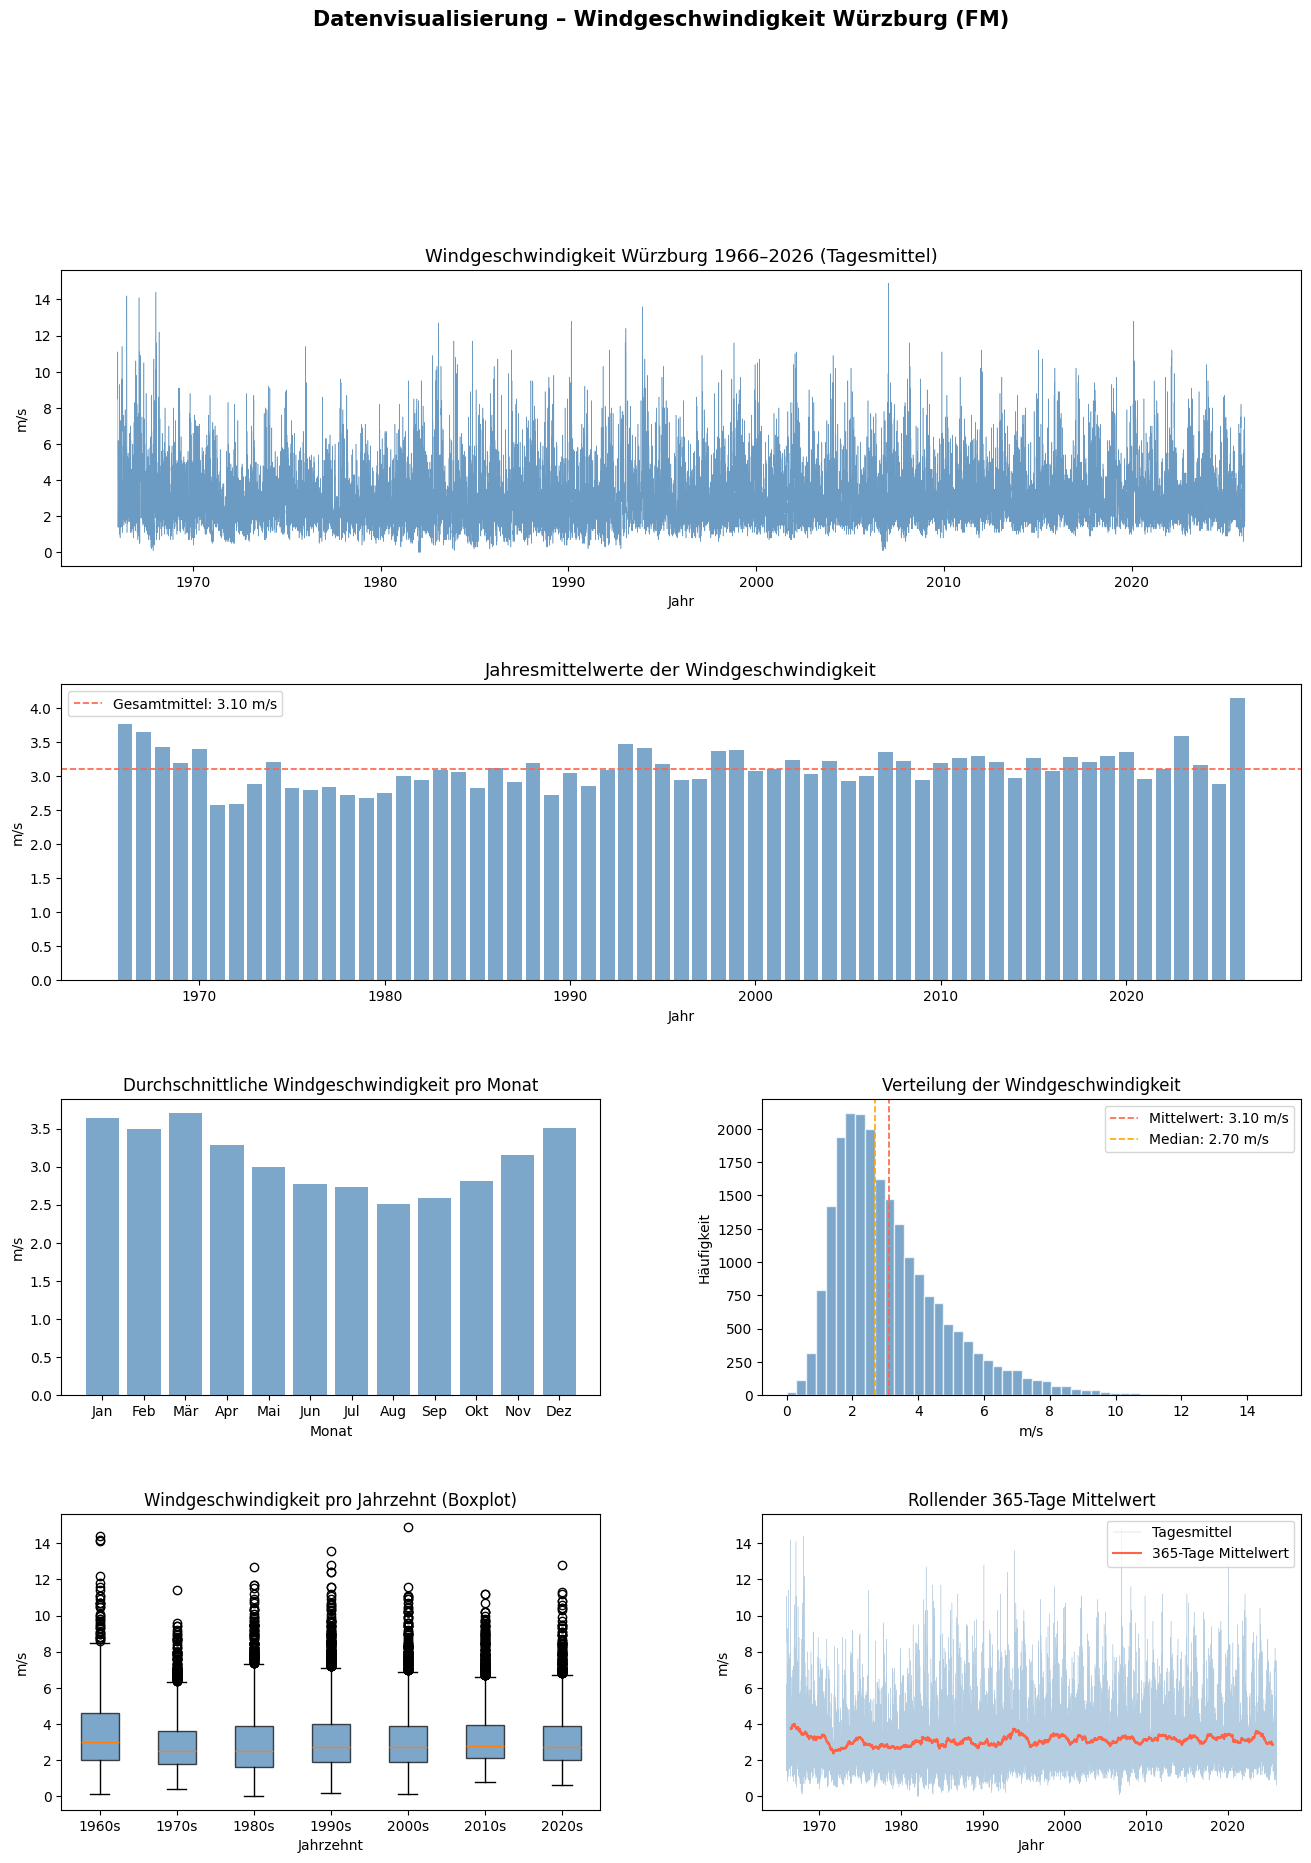

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── Plot 1: Zeitreihe komplett ───────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(wind_clean, linewidth=0.4, color="steelblue", alpha=0.8)
ax1.set_title("Windgeschwindigkeit Würzburg 1966–2026 (Tagesmittel)", fontsize=13)
ax1.set_ylabel("m/s")
ax1.set_xlabel("Jahr")

# ── Plot 2: Jahresmittelwerte ────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
jahres_mittel = wind_clean.resample("YE").mean()
ax2.bar(jahres_mittel.index.year, jahres_mittel.values,
        color="steelblue", alpha=0.7, width=0.8)
ax2.axhline(wind_clean.mean(), color="tomato", linestyle="--",
            linewidth=1.2, label=f"Gesamtmittel: {wind_clean.mean():.2f} m/s")
ax2.set_title("Jahresmittelwerte der Windgeschwindigkeit", fontsize=13)
ax2.set_ylabel("m/s")
ax2.set_xlabel("Jahr")
ax2.legend()

# ── Plot 3: Monatliche Saisonalität ─────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
wind_df = wind_clean.to_frame(name="FM")
wind_df["Monat"] = wind_df.index.month
monat_mittel = wind_df.groupby("Monat")["FM"].mean()
monate_labels = ["Jan","Feb","Mär","Apr","Mai","Jun",
                 "Jul","Aug","Sep","Okt","Nov","Dez"]
ax3.bar(monate_labels, monat_mittel.values, color="steelblue", alpha=0.7)
ax3.set_title("Durchschnittliche Windgeschwindigkeit pro Monat", fontsize=12)
ax3.set_ylabel("m/s")
ax3.set_xlabel("Monat")

# ── Plot 4: Histogramm ───────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(wind_clean, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
ax4.axvline(wind_clean.mean(), color="tomato", linestyle="--",
            linewidth=1.2, label=f"Mittelwert: {wind_clean.mean():.2f} m/s")
ax4.axvline(wind_clean.median(), color="orange", linestyle="--",
            linewidth=1.2, label=f"Median: {wind_clean.median():.2f} m/s")
ax4.set_title("Verteilung der Windgeschwindigkeit", fontsize=12)
ax4.set_xlabel("m/s")
ax4.set_ylabel("Häufigkeit")
ax4.legend()

# ── Plot 5: Boxplot pro Jahrzehnt ────────────────────────────
ax5 = fig.add_subplot(gs[3, 0])
wind_df["Jahrzehnt"] = (wind_df.index.year // 10) * 10
jahrzehnte = sorted(wind_df["Jahrzehnt"].unique())
data_per_decade = [wind_df[wind_df["Jahrzehnt"] == j]["FM"].values
                   for j in jahrzehnte]
ax5.boxplot(data_per_decade, labels=[str(j)+"s" for j in jahrzehnte],
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.7))
ax5.set_title("Windgeschwindigkeit pro Jahrzehnt (Boxplot)", fontsize=12)
ax5.set_ylabel("m/s")
ax5.set_xlabel("Jahrzehnt")

# ── Plot 6: Rollender Mittelwert ─────────────────────────────
ax6 = fig.add_subplot(gs[3, 1])
rolling_365 = wind_clean.rolling(window=365, center=True).mean()
ax6.plot(wind_clean, linewidth=0.3, color="steelblue", alpha=0.4, label="Tagesmittel")
ax6.plot(rolling_365, linewidth=1.5, color="tomato", label="365-Tage Mittelwert")
ax6.set_title("Rollender 365-Tage Mittelwert", fontsize=12)
ax6.set_ylabel("m/s")
ax6.set_xlabel("Jahr")
ax6.legend()

plt.suptitle("Datenvisualisierung – Windgeschwindigkeit Würzburg (FM)",
             fontsize=15, fontweight="bold", y=1.01)
plt.show()

## - Stationaritätstests

Stationaritätstests prüfen in der Zeitreihenanalyse, ob statistische Eigenschaften wie Mittelwert und Varianz über die Zeit konstant bleiben. Dies ist entscheidend für verlässliche Prognosemodelle, da nicht-stationäre Daten oft zu falschen Ergebnissen führen. Die gängigsten Methoden sind visuelle Inspektion (Plots), der Augmented Dickey-Fuller (ADF) Test und der KPSS-Test.

In [4]:

from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

# ── ADF Test ─────────────────────────────────────────────────
adf_result = adfuller(wind_clean, autolag="AIC")

print(" Augmented Dickey-Fuller Test (ADF) ")
print(f"H0: Die Zeitreihe hat eine Einheitswurzel (nicht stationär)")
print(f"H1: Die Zeitreihe ist stationär\n")
print(f"  Teststatistik:    {adf_result[0]:.4f}")
print(f"  p-Wert:           {adf_result[1]:.4f}")
print(f"  Lags verwendet:   {adf_result[2]}")
print(f"  Kritische Werte:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")
if adf_result[1] < 0.05:
    print(f"\n  → p < 0.05: H0 wird abgelehnt ✅ Zeitreihe ist stationär")
else:
    print(f"\n  → p > 0.05: H0 wird nicht abgelehnt ❌ Zeitreihe ist nicht stationär")

# ── KPSS Test ────────────────────────────────────────────────
kpss_result = kpss(wind_clean, regression="c", nlags="auto")

print("\n KPSS Test ")
print(f"H0: Die Zeitreihe ist stationär")
print(f"H1: Die Zeitreihe ist nicht stationär\n")
print(f"  Teststatistik:    {kpss_result[0]:.4f}")
print(f"  p-Wert:           {kpss_result[1]:.4f}")
print(f"  Lags verwendet:   {kpss_result[2]}")
print(f"  Kritische Werte:")
for key, val in kpss_result[3].items():
    print(f"    {key}: {val:.4f}")
if kpss_result[1] > 0.05:
    print(f"\n  → p > 0.05: H0 wird nicht abgelehnt ✅ Zeitreihe ist stationär")
else:
    print(f"\n  → p < 0.05: H0 wird abgelehnt ❌ Zeitreihe ist nicht stationär")

 Augmented Dickey-Fuller Test (ADF) 
H0: Die Zeitreihe hat eine Einheitswurzel (nicht stationär)
H1: Die Zeitreihe ist stationär

  Teststatistik:    -22.7750
  p-Wert:           0.0000
  Lags verwendet:   23
  Kritische Werte:
    1%: -3.4306
    5%: -2.8617
    10%: -2.5668

  → p < 0.05: H0 wird abgelehnt ✅ Zeitreihe ist stationär

 KPSS Test 
H0: Die Zeitreihe ist stationär
H1: Die Zeitreihe ist nicht stationär

  Teststatistik:    0.5562
  p-Wert:           0.0290
  Lags verwendet:   61
  Kritische Werte:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

  → p < 0.05: H0 wird abgelehnt ❌ Zeitreihe ist nicht stationär


## - Differenz bilden



Da der KPSS-Test auf einen schwachen Trend hindeutet, wird die Zeitreihe einmal differenziert (d=1). Anstatt der absoluten Windgeschwindigkeit wird damit die tägliche Veränderung modelliert. Nach der Differenzierung bestätigen beide Tests (ADF und KPSS) Stationarität, womit die Voraussetzung für die ARIMA-Modellierung erfüllt ist.

=== Tests auf differenzierte Reihe (d=1) ===

ADF  p-Wert:  0.0000 → ✅ Stationär
KPSS p-Wert:  0.1000 → ✅ Stationär


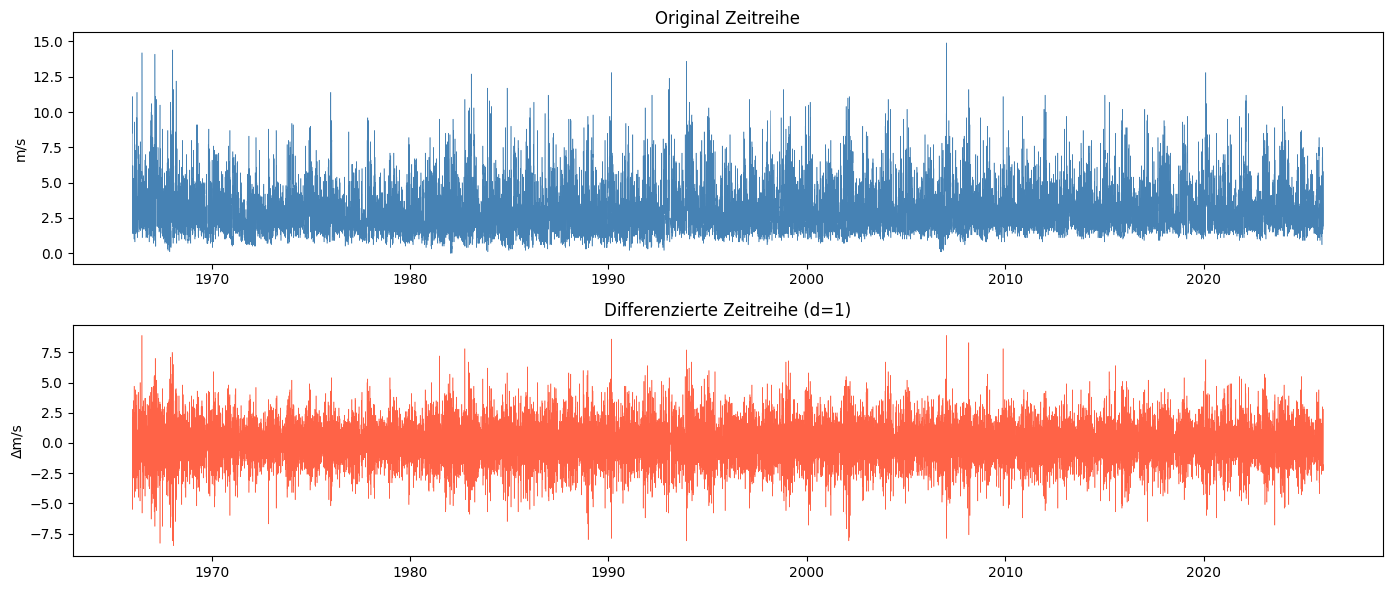

In [5]:
# Schwache Stationalität ──> erste Differenz bilden
wind_diff = wind_clean.diff().dropna()

# ── ADF auf differenzierte Reihe ─────────────────────────────
adf_diff = adfuller(wind_diff, autolag="AIC")
kpss_diff = kpss(wind_diff, regression="c", nlags="auto")

print("=== Tests auf differenzierte Reihe (d=1) ===\n")
print(f"ADF  p-Wert:  {adf_diff[1]:.4f} → {'✅ Stationär' if adf_diff[1] < 0.05 else '❌ Nicht stationär'}")
print(f"KPSS p-Wert:  {kpss_diff[1]:.4f} → {'✅ Stationär' if kpss_diff[1] > 0.05 else '❌ Nicht stationär'}")

# ── Plot zum Vergleich ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(wind_clean, linewidth=0.4, color="steelblue")
axes[0].set_title("Original Zeitreihe")
axes[0].set_ylabel("m/s")

axes[1].plot(wind_diff, linewidth=0.4, color="tomato")
axes[1].set_title("Differenzierte Zeitreihe (d=1)")
axes[1].set_ylabel("Δm/s")
plt.tight_layout()
plt.show()

## - Autocorrelation & Partial Autocorrelation

Die ACF der differenzierten Windgeschwindigkeitsreihe zeigt einen abrupten Abfall nach Lag 2, während die PACF langsam gegen null konvergiert. Dieses Muster deutet auf einen MA-dominanten Prozess hin (p klein, q größer), bei dem vergangene Prognosefehler einen stärkeren Einfluss auf den aktuellen Wert haben als vergangene Beobachtungen selbst.

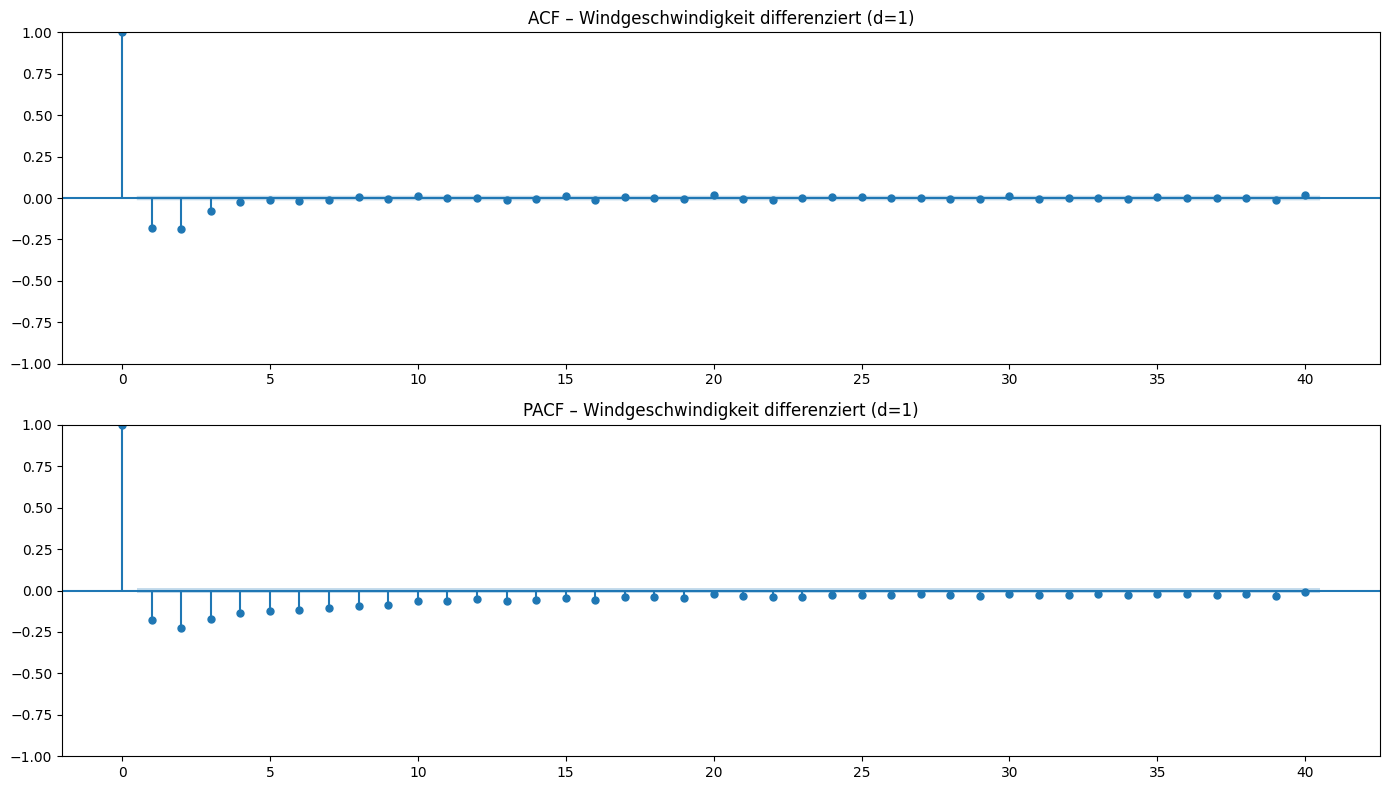

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
# ── ACF und PACF auf der differenzierten Reihe (d=1) ─────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(wind_diff, lags=40, ax=axes[0],
         title="ACF – Windgeschwindigkeit differenziert (d=1)")
plot_pacf(wind_diff, lags=40, ax=axes[1],
          title="PACF – Windgeschwindigkeit differenziert (d=1)",
          method="ywm")

plt.tight_layout()
plt.show()

## - Split & Grid Search

Der Datensatz wird chronologisch aufgeteilt: die letzten 10 Tage (02.01.2026 – 11.01.2026) dienen als Testdaten, alle vorherigen Beobachtungen als Trainingsdaten. Eine zufällige Aufteilung ist bei Zeitreihen nicht zulässig, da die zeitliche Reihenfolge der Beobachtungen erhalten bleiben muss. Auf den Trainingsdaten wird ein Grid Search über verschiedene ARIMA(p,1,q) Kombinationen durchgeführt. Als Selektionskriterium wird das BIC (SC) verwendet, da es Modellkomplexität stärker bestraft als das AIC und somit sparsamere Modelle bevorzugt. Das beste Modell nach BIC ist ARIMA(1,1,2).

In [7]:
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ── Split ─────────────────────────────────────────────────────
wind_train = wind_clean.iloc[:-10]
wind_test  = wind_clean.iloc[-10:]

print(f"Train: {wind_train.index[0].date()} bis {wind_train.index[-1].date()} ({len(wind_train)} Tage)")
print(f"Test:  {wind_test.index[0].date()} bis {wind_test.index[-1].date()} ({len(wind_test)} Tage)")

# ── Grid Search auf Trainingsdaten ────────────────────────────
results = []

for p, q in product(range(3), range(1, 4)):
    try:
        fit = ARIMA(wind_train, order=(p, 1, q)).fit()
        results.append({
            "Modell": f"ARIMA({p},1,{q})",
            "AIC":    round(fit.aic, 2),
            "SC":     round(fit.bic, 2),
            "HQ":     round(fit.hqic, 2)
        })
    except Exception:
        continue

results_df = pd.DataFrame(results).sort_values("SC").reset_index(drop=True)
print("\n=== Grid Search Ergebnisse (sortiert nach SC) ===\n")
print(results_df.to_string(index=False))
print(f"\n→ Bestes Modell nach SC: {results_df.iloc[0]['Modell']}")

Train: 1966-01-01 bis 2026-01-01 (21916 Tage)
Test:  2026-01-02 bis 2026-01-11 (10 Tage)

=== Grid Search Ergebnisse (sortiert nach SC) ===

      Modell      AIC       SC       HQ
ARIMA(1,1,2) 76827.54 76859.52 76837.96
ARIMA(1,1,3) 76823.64 76863.61 76836.66
ARIMA(2,1,1) 76834.06 76866.04 76844.47
ARIMA(2,1,2) 76826.10 76866.07 76839.12
ARIMA(2,1,3) 76831.50 76879.47 76847.13
ARIMA(1,1,1) 76909.44 76933.42 76917.25
ARIMA(0,1,3) 77044.90 77076.88 77055.31
ARIMA(0,1,2) 77811.25 77835.23 77819.06
ARIMA(0,1,1) 80612.99 80628.98 80618.20

→ Bestes Modell nach SC: ARIMA(1,1,2)


## - Cross Validation

Zur Validierung des gewählten Modells ARIMA(1,1,2) wird eine 5-Fold Time Series Cross Validation auf den Trainingsdaten durchgeführt. Die Trainingsdaten werden in 5 aufeinanderfolgende Partitionen aufgeteilt, wobei in jedem Fold ein Subset als Testset und alle vorherigen Daten als Trainingsset dienen. Dies entspricht dem Walk-Forward Prinzip und verhindert, dass das Modell zukünftige Daten beim Training sieht. Der durchschnittliche RMSE über alle 5 Folds beträgt 1.90 m/s.



In [8]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

FINAL_ORDER = (1, 1, 2)
N_SPLITS    = 5

tscv         = TimeSeriesSplit(n_splits=N_SPLITS)
fold_results = []

print(f"=== 5-Fold Cross Validation – ARIMA{FINAL_ORDER} ===\n")

for fold, (idx_tr, idx_te) in enumerate(tscv.split(wind_train)):
    train_fold = wind_train.iloc[idx_tr]
    test_fold  = wind_train.iloc[idx_te]
    try:
        fit  = ARIMA(train_fold, order=FINAL_ORDER).fit()
        fc   = fit.forecast(steps=len(test_fold))
        fc.index = test_fold.index
        mse  = mean_squared_error(test_fold, fc)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(test_fold, fc)
        fold_results.append({
            "Fold":  f"Fold {fold+1}",
            "MSE":   round(mse,  4),
            "RMSE":  round(rmse, 4),
            "MAE":   round(mae,  4),
        })
        print(f"  Fold {fold+1}: RMSE={rmse:.4f} | MAE={mae:.4f}")
    except Exception as e:
        print(f"  Fold {fold+1}: Fehler — {e}")

avg_rmse = np.mean([r["RMSE"] for r in fold_results])
avg_mae  = np.mean([r["MAE"]  for r in fold_results])
avg_mse  = np.mean([r["MSE"]  for r in fold_results])

print(f"\n  Ø MSE:  {avg_mse:.4f}")
print(f"  Ø RMSE: {avg_rmse:.4f}")
print(f"  Ø MAE:  {avg_mae:.4f}")

=== 5-Fold Cross Validation – ARIMA(1, 1, 2) ===

  Fold 1: RMSE=1.7300 | MAE=1.3896
  Fold 2: RMSE=1.8911 | MAE=1.3951
  Fold 3: RMSE=1.7021 | MAE=1.2575
  Fold 4: RMSE=1.6553 | MAE=1.1926
  Fold 5: RMSE=1.6735 | MAE=1.3167

  Ø MSE:  3.0013
  Ø RMSE: 1.7304
  Ø MAE:  1.3103


##- Evaluation

Das ARIMA(1,1,2) Modell wird auf den Trainingsdaten gefittet und prognostiziert die letzten 10 Tage (02.01.2026 – 11.01.2026), für die reale Beobachtungen vorliegen. Die Fehlermetriken MSE, RMSE, MAE und MAPE werden berechnet, um die Prognosegüte objektiv zu beurteilen. Der RMSE zeigt die durchschnittliche Abweichung in m/s, während der hohe MAPE typisch für Windgeschwindigkeitsdaten ist, da an Tagen mit sehr geringer Windgeschwindigkeit kleine absolute Fehler zu hohen prozentualen Fehlern führen.

In [9]:
fit_final = ARIMA(wind_train, order=FINAL_ORDER).fit()
fc_final  = fit_final.forecast(steps=len(wind_test))
fc_final.index = wind_test.index

mse_test  = mean_squared_error(wind_test, fc_final)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(wind_test, fc_final)
mape_test = np.mean(np.abs((wind_test.values - fc_final.values) /
                             wind_test.values)) * 100

print(f"=== Finale Evaluation auf Testdaten ===\n")
print(f"  MSE:  {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  MAE:  {mae_test:.4f}")
print(f"  MAPE: {mape_test:.4f}%")

=== Finale Evaluation auf Testdaten ===

  MSE:  2.5497
  RMSE: 1.5968
  MAE:  1.2843
  MAPE: 33.6771%


## - Prognose & Evaluation

Das finale Modell ARIMA(1,1,2) wird auf allen Daten bis zum 01.01.2026 trainiert und prognostiziert die Windgeschwindigkeit für die nächsten 10 Tage (02.01.2026 – 11.01.2026). Da für diesen Zeitraum reale Beobachtungen vorliegen, können die Prognosen direkt mit den tatsächlichen Werten verglichen und die Fehlermetriken berechnet werden. Die Prognose konvergiert schnell gegen den langfristigen Mittelwert von ~3.1 m/s, was typisches Verhalten von ARIMA-Modellen bei stark stochastischen Zeitreihen wie Windgeschwindigkeit ist. Das 95% Konfidenzintervall weitet sich mit zunehmendem Zeithorizont aus und spiegelt die wachsende Prognoseunsicherheit wider.

=== Finale Evaluation ARIMA(1, 1, 2) ===

  MSE:  2.5497
  RMSE: 1.5968
  MAE:  1.2843
  MAPE: 33.6771%

            Prognose  Tatsächlich  Unteres 95% KI  Oberes 95% KI
datum                                                           
2026-01-02     4.962          7.5           2.226          7.698
2026-01-03     3.865          6.4           0.668          7.062
2026-01-04     3.359          4.2           0.055          6.662
2026-01-05     3.125          2.7          -0.209          6.460
2026-01-06     3.017          1.9          -0.329          6.363
2026-01-07     2.967          2.3          -0.385          6.319
2026-01-08     2.944          3.0          -0.411          6.300
2026-01-09     2.934          5.8          -0.425          6.292
2026-01-10     2.929          3.5          -0.433          6.290
2026-01-11     2.927          1.7          -0.438          6.291


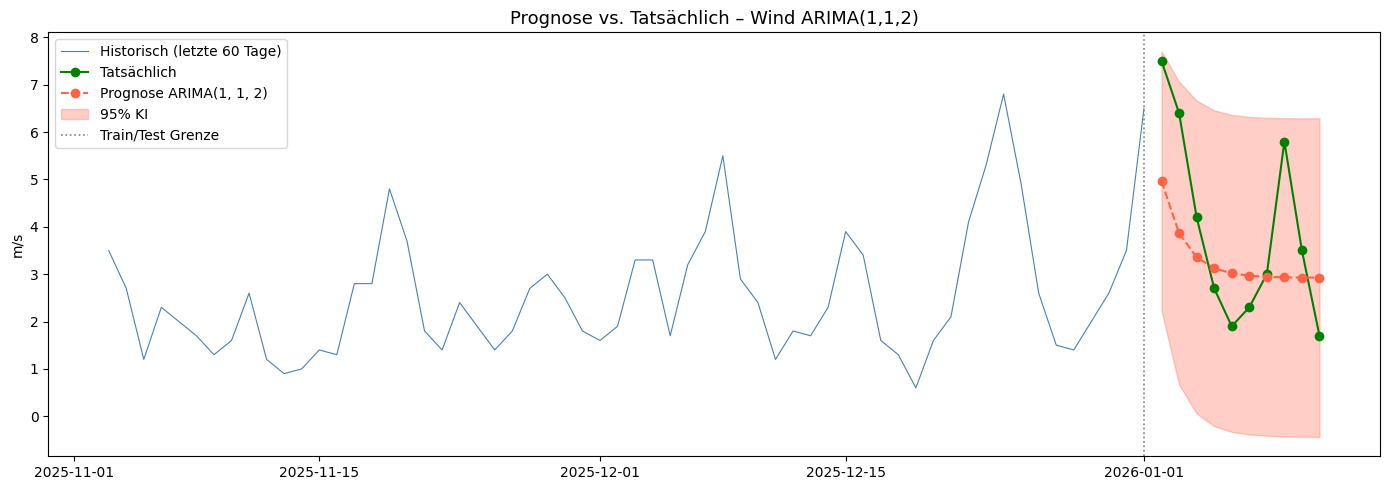

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

FINAL_ORDER = (1, 1, 2)

# ── Fit & Forecast ────────────────────────────────────────────
fit_final  = ARIMA(wind_train, order=FINAL_ORDER).fit()
fc_obj     = fit_final.get_forecast(steps=10)
fc_mean    = fc_obj.predicted_mean
fc_ci      = fc_obj.conf_int(alpha=0.05)
fc_ci.columns = ["Unteres 95% KI", "Oberes 95% KI"]
fc_mean.index = wind_test.index
fc_ci.index   = wind_test.index

# ── Fehlermetriken ────────────────────────────────────────────
mse  = mean_squared_error(wind_test, fc_mean)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(wind_test, fc_mean)
mape = np.mean(np.abs((wind_test.values - fc_mean.values) /
                       wind_test.values)) * 100

print(f"=== Finale Evaluation ARIMA{FINAL_ORDER} ===\n")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  MAPE: {mape:.4f}%")

# ── Tabelle ───────────────────────────────────────────────────
fc_df = pd.concat([
    fc_mean.rename("Prognose"),
    wind_test.rename("Tatsächlich"),
    fc_ci
], axis=1).round(3)
print(f"\n{fc_df.to_string()}")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(wind_train[-60:], linewidth=0.8,
        color="steelblue", label="Historisch (letzte 60 Tage)")
ax.plot(wind_test, linewidth=1.5, marker="o",
        color="green", label="Tatsächlich")
ax.plot(fc_mean, linewidth=1.5, linestyle="--",
        marker="o", color="tomato",
        label=f"Prognose ARIMA{FINAL_ORDER}")
ax.fill_between(fc_ci.index,
                fc_ci["Unteres 95% KI"],
                fc_ci["Oberes 95% KI"],
                alpha=0.3, color="tomato", label="95% KI")
ax.axvline(wind_train.index[-1], color="gray",
           linestyle=":", linewidth=1.2,
           label="Train/Test Grenze")
ax.set_title("Prognose vs. Tatsächlich – Wind ARIMA(1,1,2)", fontsize=13)
ax.set_ylabel("m/s")
ax.legend()
plt.tight_layout()
plt.show()

##Residuen Analyse

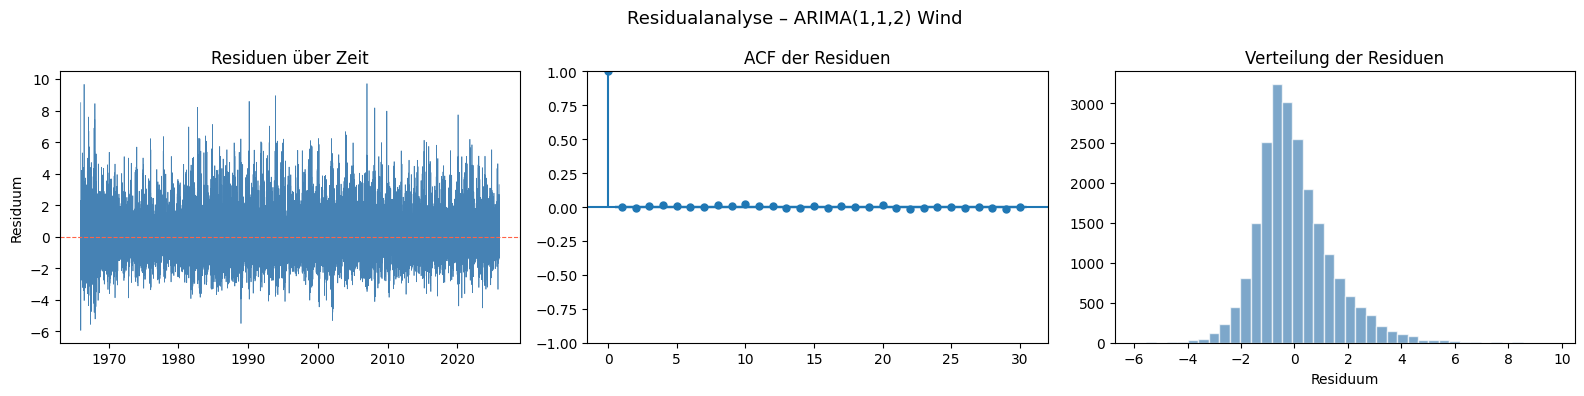

In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Residuen berechnen
residuals = pd.Series(fit_final.resid).dropna()

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuen über Zeit
axes[0].plot(residuals, linewidth=0.5, color="steelblue")
axes[0].axhline(0, color="tomato", linestyle="--", linewidth=0.8)
axes[0].set_title("Residuen über Zeit")
axes[0].set_ylabel("Residuum")

# ACF der Residuen
plot_acf(residuals, lags=30, ax=axes[1], title="ACF der Residuen")

# Histogramm
axes[2].hist(residuals, bins=40, color="steelblue",
             alpha=0.7, edgecolor="white")
axes[2].set_title("Verteilung der Residuen")
axes[2].set_xlabel("Residuum")

plt.suptitle("Residualanalyse – ARIMA(1,1,2) Wind", fontsize=13)
plt.tight_layout()
plt.show()

# ── Ljung-Box Test ────────────────────────────────────────────
lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)


## - Prognose Zukunft

In [16]:
# ── Fit on all data ───────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

FINAL_ORDER = (1, 1, 2)
final_fit   = ARIMA(wind_clean, order=FINAL_ORDER).fit()

print(f"ARIMA{FINAL_ORDER} gefittet ✅")
print(f"AIC: {final_fit.aic:.2f} | SC: {final_fit.bic:.2f} | HQ: {final_fit.hqic:.2f}")

ARIMA(1, 1, 2) gefittet ✅
AIC: 76863.05 | SC: 76895.04 | HQ: 76873.47


            Prognose  Unteres 95% KI  Oberes 95% KI
2026-01-12     2.234          -0.502          4.970
2026-01-13     2.649          -0.549          5.846
2026-01-14     2.840          -0.464          6.144
2026-01-15     2.929          -0.406          6.263
2026-01-16     2.969          -0.377          6.316
2026-01-17     2.988          -0.364          6.340
2026-01-18     2.997          -0.359          6.353
2026-01-19     3.001          -0.358          6.360
2026-01-20     3.003          -0.359          6.365
2026-01-21     3.004          -0.361          6.368


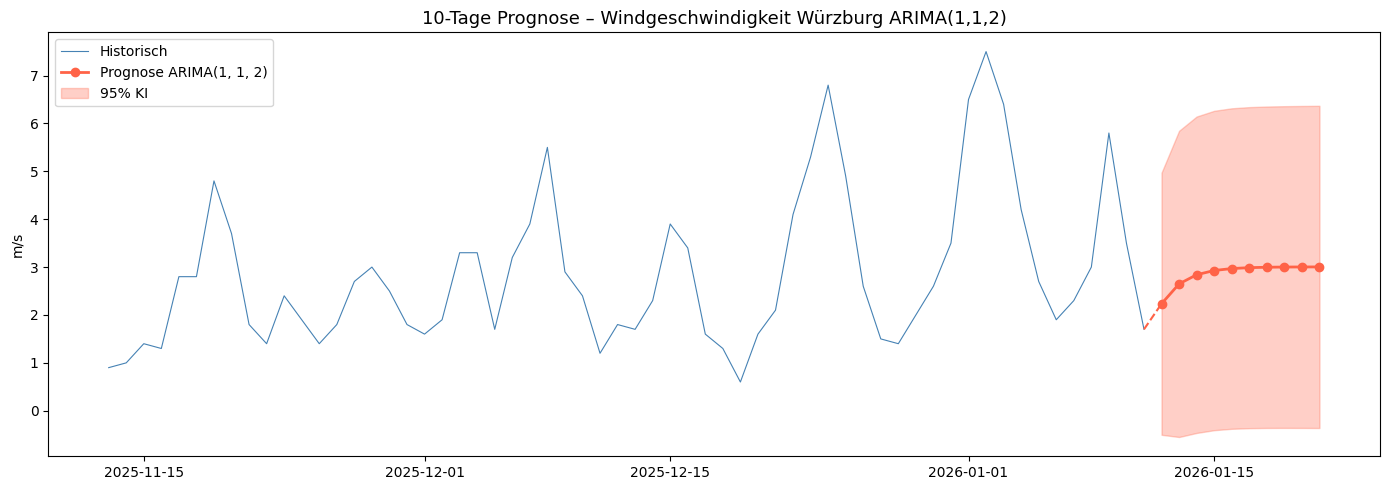

In [17]:

import matplotlib.pyplot as plt
import pandas as pd

fc_obj        = final_fit.get_forecast(steps=10)
fc_mean       = fc_obj.predicted_mean
fc_ci         = fc_obj.conf_int(alpha=0.05)
fc_ci.columns = ["Unteres 95% KI", "Oberes 95% KI"]

# Tabelle
fc_df = pd.concat([fc_mean.rename("Prognose"), fc_ci], axis=1).round(3)
print(fc_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(wind_clean[-60:], linewidth=0.8,
        color="steelblue", label="Historisch")
ax.plot([wind_clean.index[-1], fc_mean.index[0]],
        [wind_clean.iloc[-1],  fc_mean.iloc[0]],
        color="tomato", linewidth=1.5, linestyle="--")
ax.plot(fc_mean, color="tomato", linewidth=2,
        marker="o", label=f"Prognose ARIMA{FINAL_ORDER}")
ax.fill_between(fc_ci.index,
                fc_ci["Unteres 95% KI"],
                fc_ci["Oberes 95% KI"],
                alpha=0.3, color="tomato", label="95% KI")

ax.set_title(f"10-Tage Prognose – Windgeschwindigkeit Würzburg ARIMA(1,1,2)", fontsize=13)
ax.set_ylabel("m/s")
ax.legend()
plt.tight_layout()
plt.show()